# Modelo preliminar de clasificación

**CC3084 · Ciencia de Datos · Universidad del Valle de Guatemala · Semestre II, 2026**

Este cuaderno cubre la parte del **ejercicio 6** que corresponde a la entrega de avance: la
partición del conjunto, un baseline contra el cual comparar, varias combinaciones de
representación del texto y algoritmo de clasificación, y la descripción del modelo
preliminar seleccionado.

El alcance es deliberadamente el del avance. El enunciado pide para esta fecha la
*"descripción del modelo preliminar de clasificación"*, no la exploración exhaustiva de
hiperparámetros. Lo que aquí se establece es la **infraestructura de evaluación** —partición
congelada, baseline, función de evaluación reutilizable y métrica de selección— sobre la que
la entrega final escalará a más combinaciones.

Dos hipótesis que dejaron planteadas los cuadernos anteriores se ponen a prueba aquí:

1. El análisis exploratorio recomendó **incorporar `keyword` como característica**.
2. El análisis exploratorio predijo que **los errores se concentrarían en el vocabulario de
   uso figurado**, es decir en las keywords de tasa de desastre intermedia.

Ambas se verifican con datos más abajo, y una de las dos no sobrevive a la comprobación.

In [1]:
import sys
from pathlib import Path
from urllib.parse import unquote

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ / 'src'))

import config
from carga import cargar_tweets
from preprocesamiento import pipeline_texto

config.asegurar_directorios()

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = config.FIG_DPI
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.width', 170)
pd.set_option('display.max_colwidth', 90)

def guardar(fig, nombre):
    ruta = config.FIGURES / nombre
    fig.savefig(ruta)
    print(f'figura guardada: {ruta.name}')
    return ruta

def guardar_tabla(df, nombre):
    ruta = config.TABLES / nombre
    df.to_csv(ruta, index=False, encoding='utf-8')
    print(f'tabla guardada: {ruta.name}')
    return ruta

print(f'Semilla del laboratorio: SEED = {config.SEED}')
print(f'Proporción de prueba:    TEST_SIZE = {config.TEST_SIZE}')

Semilla del laboratorio: SEED = 42
Proporción de prueba:    TEST_SIZE = 0.2


## Carga y reconstrucción del texto procesado

El cuaderno de preprocesamiento genera `text_clean` en memoria pero no lo persiste en disco,
así que aquí se reconstruye llamando a `pipeline_texto` con **exactamente los mismos
argumentos**. No es una duplicación accidental: es la convención del equipo, la misma que
sigue `03_ngramas.ipynb`, y hace que cada cuaderno sea reproducible por separado sin
depender de que otro se haya ejecutado antes.

El argumento que importa es `quitar_numeros=False`. El análisis exploratorio midió que los
dígitos aparecen en el 72.74% de los tweets de desastre real contra el 49.90% del resto, así
que eliminarlos destruiría señal. La función los quita por defecto; aquí se desactiva a
propósito.

In [2]:
df = cargar_tweets(deduplicar=True, verbose=True)

df['text_clean'] = df['text'].apply(
    lambda t: ' '.join(pipeline_texto(t, modo='clasificacion', reduccion='lema', quitar_numeros=False)))
df['text_stem'] = df['text'].apply(
    lambda t: ' '.join(pipeline_texto(t, modo='clasificacion', reduccion='stem', quitar_numeros=False)))

# `keyword` viene con los espacios codificados como %20 en el archivo original.
df['keyword_norm'] = df['keyword'].fillna('sin_keyword').map(lambda k: unquote(str(k)).lower())

print()
print(f'{len(df):,} tweets listos, {df.keyword_norm.nunique()} keywords distintas.')
df[['text', 'text_clean', 'keyword_norm', 'target']].head(3)

Leído train.csv: 7,613 filas x 5 columnas
Deduplicación
  Filas originales................. 7,613
  Textos con etiqueta contradictoria 18 (55 filas eliminadas)
  Duplicados exactos eliminados.... 73
  Filas finales.................... 7,485 (128 eliminadas en total)



7,485 tweets listos, 222 keywords distintas.


,text,text_clean,keyword_norm,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason earthquake may allah forgive,sin_keyword,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,sin_keyword,1
2,All residents asked to 'shelter in place' are being notified by officers. No other eva...,resident asked shelter place notified officer no evacuation shelter place order expected,sin_keyword,1


## Partición estratificada, y por qué se congela

La partición se hace **después** de la deduplicación. El orden importa: `carga.py` elimina
128 filas duplicadas o con etiqueta contradictoria, y si esa limpieza ocurriera después de
partir, el mismo tweet podría quedar a ambos lados y el modelo sería evaluado sobre textos
que ya vio. La métrica saldría optimista por una razón puramente artificial.

Se usa `stratify=y` para que ambos lados conserven la proporción 57.41% / 42.59% del corpus
completo. Sin estratificar, el azar podría dejar un conjunto de prueba con una mezcla de
clases distinta a la real y las métricas no serían comparables entre modelos.

La partición se guarda en `data/processed/particion.parquet`, la ruta que `src/config.py`
declara. Congelarla tiene un propósito concreto: los ejercicios 8 a 10 de la entrega final
entrenan de nuevo el clasificador añadiendo una variable de negatividad, y esa comparación
solo tiene sentido si **el conjunto de prueba es exactamente el mismo**. Si cada persona
volviera a partir por su cuenta, cualquier diferencia de métrica podría deberse al cambio de
partición y no a la variable nueva.

In [3]:
X = df[['id', 'text', 'text_clean', 'text_stem', 'keyword_norm']]
y = df['target']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=config.TEST_SIZE, stratify=y, random_state=config.SEED)

resumen_particion = pd.DataFrame({
    'entrenamiento': y_tr.value_counts().sort_index(),
    'prueba': y_te.value_counts().sort_index(),
    '% entrenamiento': (y_tr.value_counts(normalize=True).sort_index() * 100).round(2),
    '% prueba': (y_te.value_counts(normalize=True).sort_index() * 100).round(2),
})
resumen_particion.index = resumen_particion.index.map(config.ETIQUETAS)

print(f'Entrenamiento: {len(X_tr):,} tweets   Prueba: {len(X_te):,} tweets')
print()
resumen_particion

Entrenamiento: 5,988 tweets   Prueba: 1,497 tweets



,entrenamiento,prueba,% entrenamiento,% prueba
target,,,,
no desastre,3438,859,57.41,57.38
desastre,2550,638,42.59,42.62


In [4]:
# Se congela la partición para que la entrega final use exactamente el mismo conjunto de prueba.
particion = df[['id', 'target']].copy()
particion['conjunto'] = np.where(particion['id'].isin(X_tr['id']), 'entrenamiento', 'prueba')
particion.to_parquet(config.PARTICION, index=False)

print(f'Partición congelada en {config.PARTICION.relative_to(RAIZ)}')
print(particion.conjunto.value_counts().to_string())

Partición congelada en data/processed/particion.parquet
conjunto
entrenamiento    5988
prueba           1497


**Interpretación.** Las proporciones de clase coinciden hasta la segunda cifra decimal entre
entrenamiento (57.41% / 42.59%) y prueba (57.38% / 42.62%). La estratificación funcionó: el
conjunto de prueba es una muestra representativa del corpus y no una porción sesgada hacia
una clase.

## El baseline, y por qué no se puede omitir

Antes de entrenar nada hay que fijar el piso. `DummyClassifier(strategy='most_frequent')`
responde siempre "no desastre", la clase mayoritaria, sin mirar el texto. Su exactitud es
del 57.38%, que es exactamente la proporción de la clase mayoritaria en el conjunto de
prueba.

Ese número es la razón por la que **la exactitud no puede ser la métrica de selección de
este laboratorio**. Un modelo que reportara un 70% de exactitud suena razonable hasta que se
recuerda que no mirar el texto en absoluto ya alcanza un 57%. Su macro-F1, en cambio, es de
0.3646: la media entre un F1 de 0.7292 en la clase que siempre acierta y un F1 de 0 en la
clase que nunca detecta. La macro-F1 sí captura que el modelo es inútil para lo único que
interesa, que es encontrar los desastres reales.

In [5]:
def evaluar_combinacion(nombre, representacion, clasificador, columna='text_clean', registro=None):
    """Entrena una combinación representación + clasificador y devuelve una fila de métricas.

    El vectorizador va SIEMPRE dentro del `Pipeline`, nunca ajustado por separado sobre el
    conjunto completo. Esa es la garantía de que no hay fuga de información: cuando
    `pipe.fit` se ejecuta, el vocabulario y los pesos IDF se calculan usando únicamente el
    conjunto de entrenamiento. Las palabras que solo existen en el conjunto de prueba
    simplemente no forman parte del vocabulario, que es justo lo que ocurriría con un tweet
    nuevo en producción.
    """
    pipe = Pipeline([('vec', representacion), ('clf', clasificador)])
    pipe.fit(X_tr[columna], y_tr)
    pred = pipe.predict(X_te[columna])

    p, r, f, _ = precision_recall_fscore_support(y_te, pred, labels=[0, 1], zero_division=0)
    fila = {
        'modelo': nombre,
        'representacion': type(representacion).__name__,
        'algoritmo': type(clasificador).__name__,
        'texto': columna,
        'accuracy': accuracy_score(y_te, pred),
        'precision_no_desastre': p[0], 'recall_no_desastre': r[0], 'f1_no_desastre': f[0],
        'precision_desastre': p[1], 'recall_desastre': r[1], 'f1_desastre': f[1],
        'macro_f1': f1_score(y_te, pred, average='macro'),
    }
    if registro is not None:
        registro.append(fila)
    return pipe, pred, fila


resultados = []
modelos = {}

pipe_base, pred_base, fila_base = evaluar_combinacion(
    'Baseline (clase mayoritaria)',
    CountVectorizer(), DummyClassifier(strategy='most_frequent'), registro=resultados)
modelos['Baseline (clase mayoritaria)'] = pipe_base

print(f"Baseline  accuracy = {fila_base['accuracy']:.4f}   macro-F1 = {fila_base['macro_f1']:.4f}")

Baseline  accuracy = 0.5738   macro-F1 = 0.3646


## Combinaciones evaluadas

Para el avance se evalúan cinco combinaciones además del baseline. No son las doce que
contempla la entrega final: el objetivo de hoy es dejar montada la infraestructura y tener
un modelo preliminar descrito, no agotar el espacio de búsqueda.

| Combinación | Qué pone a prueba |
|---|---|
| TF-IDF (1,1) + Regresión logística | El modelo de referencia, solo unigramas |
| TF-IDF (1,2) + Regresión logística | Si los bigramas que recomendó el análisis de n-gramas aportan |
| TF-IDF (1,2) + Naive Bayes multinomial | Un generativo rápido, el clásico para texto |
| Bolsa de palabras (1,2) + LinearSVC | Conteo crudo en vez de TF-IDF, con un margen máximo |
| TF-IDF (1,2) + Regresión logística sobre `text_stem` | Si el stemming supera a la lematización |

Dos decisiones de configuración se aplican a todas:

- **`min_df=2`** descarta los términos que aparecen en un solo documento. El análisis de
  n-gramas advirtió que el vocabulario de bigramas es muy disperso; sin este filtro, el
  modelo memoriza tweets concretos en vez de aprender patrones que generalicen.
- **`class_weight='balanced'`** en los modelos que lo admiten compensa el desbalance
  57/43 penalizando más los errores sobre la clase minoritaria, que es la de interés.

In [6]:
_, pred_lr1, _ = evaluar_combinacion(
    'TF-IDF (1,1) + LogReg',
    TfidfVectorizer(ngram_range=(1, 1), min_df=2),
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=config.SEED),
    registro=resultados)

pipe_lr2, pred_lr2, _ = evaluar_combinacion(
    'TF-IDF (1,2) + LogReg',
    TfidfVectorizer(ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=config.SEED),
    registro=resultados)
modelos['TF-IDF (1,2) + LogReg'] = pipe_lr2

_, pred_nb, _ = evaluar_combinacion(
    'TF-IDF (1,2) + MultinomialNB',
    TfidfVectorizer(ngram_range=(1, 2), min_df=2),
    MultinomialNB(),
    registro=resultados)

_, pred_svc, _ = evaluar_combinacion(
    'BoW (1,2) + LinearSVC',
    CountVectorizer(ngram_range=(1, 2), min_df=2),
    LinearSVC(class_weight='balanced', random_state=config.SEED),
    registro=resultados)

_, pred_stem, _ = evaluar_combinacion(
    'TF-IDF (1,2) + LogReg sobre text_stem',
    TfidfVectorizer(ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=config.SEED),
    columna='text_stem',
    registro=resultados)

tabla = pd.DataFrame(resultados).sort_values('macro_f1', ascending=False).reset_index(drop=True)
guardar_tabla(tabla, 'metricas_preliminares.csv')

columnas_vista = ['modelo', 'accuracy', 'f1_no_desastre', 'precision_desastre',
                  'recall_desastre', 'f1_desastre', 'macro_f1']
tabla[columnas_vista].round(4)

tabla guardada: metricas_preliminares.csv


,modelo,accuracy,f1_no_desastre,precision_desastre,recall_desastre,f1_desastre,macro_f1
0,"TF-IDF (1,2) + LogReg",0.7923,0.8232,0.7739,0.7241,0.7482,0.7857
1,"TF-IDF (1,1) + LogReg",0.7923,0.8234,0.7748,0.7226,0.7478,0.7856
2,"TF-IDF (1,2) + LogReg sobre text_stem",0.7896,0.8215,0.7733,0.7163,0.7437,0.7826
3,"TF-IDF (1,2) + MultinomialNB",0.7902,0.8349,0.8568,0.6097,0.7125,0.7737
4,"BoW (1,2) + LinearSVC",0.7602,0.7987,0.7435,0.6677,0.7036,0.7511
5,Baseline (clase mayoritaria),0.5738,0.7292,0.0000,0.0000,0.0000,0.3646


figura guardada: modelo_comparacion_macrof1.png


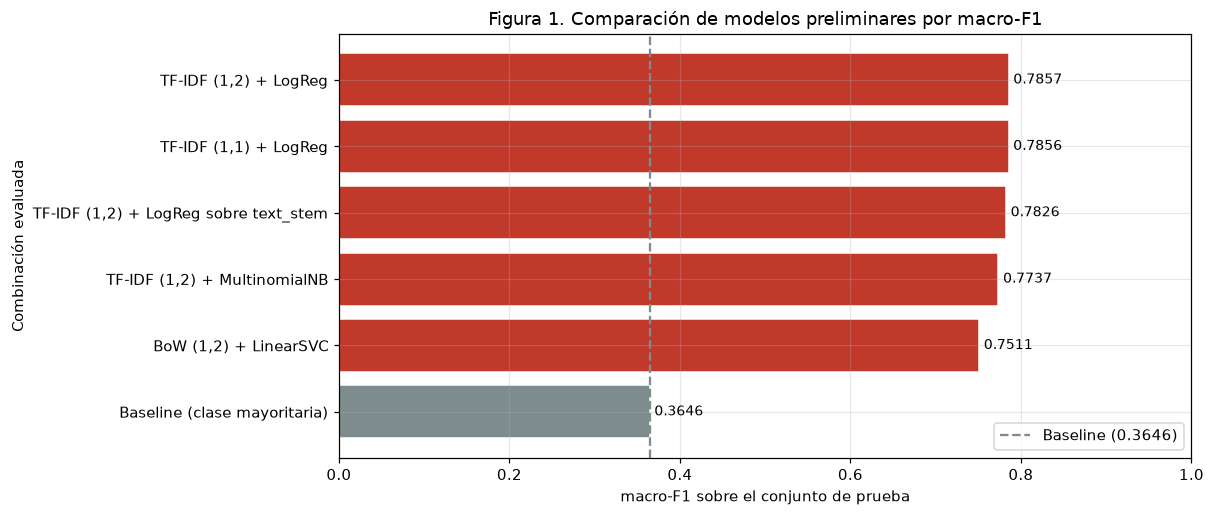

In [7]:
fig, ax = plt.subplots(figsize=(config.FIG_ANCHO, config.FIG_ALTO))
orden = tabla.sort_values('macro_f1')
colores = [config.COLOR_NEUTRO if 'Baseline' in m else config.COLOR_DESASTRE for m in orden.modelo]

barras = ax.barh(orden.modelo, orden.macro_f1, color=colores, edgecolor='white')
ax.bar_label(barras, fmt='%.4f', padding=3, fontsize=9)
ax.axvline(fila_base['macro_f1'], color=config.COLOR_NEUTRO, linestyle='--', linewidth=1.5,
           label=f"Baseline ({fila_base['macro_f1']:.4f})")
ax.set_xlabel('macro-F1 sobre el conjunto de prueba')
ax.set_ylabel('Combinación evaluada')
ax.set_title('Figura 1. Comparación de modelos preliminares por macro-F1')
ax.set_xlim(0, 1.0)
ax.legend(loc='lower right')
guardar(fig, 'modelo_comparacion_macrof1.png')
plt.show()

**Interpretación.** Las cuatro combinaciones que usan `text_clean` superan al baseline por
más de 0.38 puntos de macro-F1, así que el texto sí contiene señal aprovechable y el modelo
está aprendiendo algo real y no la proporción de clases.

Tres lecturas concretas:

**Los bigramas casi no aportan.** TF-IDF (1,2) obtiene 0.7857 de macro-F1 y TF-IDF (1,1)
obtiene 0.7856. La diferencia es de una diezmilésima, muy por debajo de lo que cabe atribuir
a una elección de partición. El análisis de n-gramas había recomendado incluirlos porque
capturan colocaciones reales como `suicide bomber` u `oil spill`, y esas colocaciones
existen; lo que muestra este resultado es que **el aporte de información de esos bigramas ya
estaba contenido en sus unigramas** para efectos de clasificación. Se conserva el rango (1,2)
como configuración preliminar porque no perjudica y porque deja abierta la puerta a que ayude
al combinarse con otros ajustes en la entrega final, pero **queda registrado que hoy no es la
palanca que mejora el modelo**.

**Naive Bayes cambia el equilibrio, no el nivel.** Su exactitud es prácticamente igual a la
de la regresión logística (0.7902 contra 0.7923), pero reparte los errores de forma muy
distinta: alcanza la mayor precisión de todos en la clase desastre (0.8568) a costa de la
peor exhaustividad (0.6097). Traducido: cuando dice que un tweet es un desastre acierta más
que ningún otro, pero deja pasar casi cuatro de cada diez desastres reales. Para un problema
donde no detectar un desastre real es el error caro, ese intercambio es el equivocado, y es
exactamente lo que la macro-F1 penaliza y la exactitud habría ocultado.

**El stemming no supera a la lematización**, lo que respalda la elección de `text_clean`
como columna de trabajo que ya había hecho el cuaderno de preprocesamiento por motivos de
interpretabilidad.

## Matriz de confusión del mejor modelo

La tabla comparativa dice cuál modelo es mejor; la matriz de confusión dice **de qué tipo son
los errores que comete**, que es lo que permite decidir si el modelo sirve para el problema.

figura guardada: modelo_matriz_confusion.png


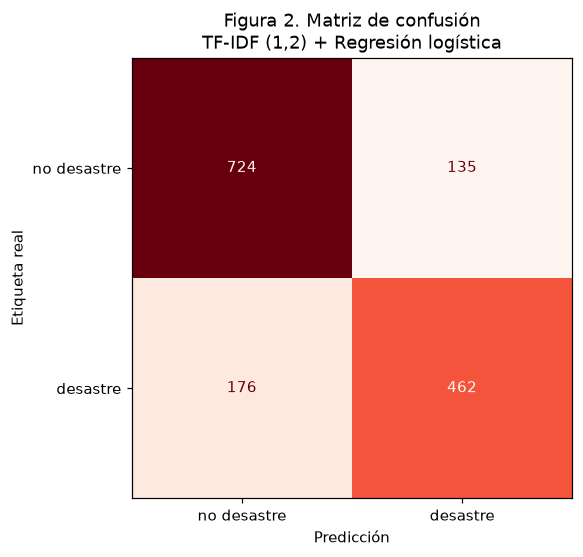

Verdaderos negativos (no desastre, acertado):  724
Falsos positivos     (falsa alarma):           135
Falsos negativos     (desastre no detectado):  176
Verdaderos positivos (desastre detectado):     462

              precision    recall  f1-score   support

 no desastre     0.8044    0.8428    0.8232       859
    desastre     0.7739    0.7241    0.7482       638

    accuracy                         0.7923      1497
   macro avg     0.7892    0.7835    0.7857      1497
weighted avg     0.7914    0.7923    0.7912      1497



In [8]:
mc = confusion_matrix(y_te, pred_lr2, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5.2))
disp = ConfusionMatrixDisplay(confusion_matrix=mc,
                              display_labels=[config.ETIQUETAS[0], config.ETIQUETAS[1]])
disp.plot(ax=ax, cmap='Reds', colorbar=False, values_format='d')
ax.set_title('Figura 2. Matriz de confusión\nTF-IDF (1,2) + Regresión logística')
ax.set_xlabel('Predicción')
ax.set_ylabel('Etiqueta real')
ax.grid(False)
guardar(fig, 'modelo_matriz_confusion.png')
plt.show()

vn, fp, fn, vp = mc.ravel()
print(f'Verdaderos negativos (no desastre, acertado): {vn:4d}')
print(f'Falsos positivos     (falsa alarma):          {fp:4d}')
print(f'Falsos negativos     (desastre no detectado): {fn:4d}')
print(f'Verdaderos positivos (desastre detectado):    {vp:4d}')
print()
print(classification_report(y_te, pred_lr2, target_names=[config.ETIQUETAS[0], config.ETIQUETAS[1]], digits=4))

**Interpretación.** El modelo comete 311 errores sobre 1,497 tweets de prueba, y no están
repartidos por igual: **176 son desastres reales que no detectó** (falsos negativos) frente a
135 falsas alarmas. Es el tipo de error más costoso para este problema —el propio
`config.py` declara `CLASE_POSITIVA = 1` con el comentario de que no detectar un desastre
real es el error caro— y ocurre pese a haber usado `class_weight='balanced'`.

La asimetría tiene una explicación que el análisis exploratorio ya anticipaba. La clase
"no desastre" se define por **ausencia**: incluye cualquier tema que no sea una catástrofe, y
su vocabulario es difuso. La clase "desastre" tiene un campo semántico cerrado y reconocible.
Un modelo lineal aprende bien ese campo cerrado, pero cuando un tweet de desastre real está
redactado sin el vocabulario típico, no tiene de dónde agarrarse y lo manda al cajón de
"todo lo demás". Reducir los falsos negativos es un objetivo explícito para la entrega final,
y la vía más directa es mover el umbral de decisión en lugar de dejarlo en 0.5 por defecto.

## Qué aprendió el modelo: inspección de coeficientes

La regresión logística es un modelo lineal, así que cada término del vocabulario tiene un
coeficiente cuyo signo y magnitud indican hacia qué clase empuja. Esto permite **auditar** lo
aprendido en lugar de aceptarlo como una caja negra, y además cruzarlo contra el análisis
discriminativo que el cuaderno de n-gramas hizo por una vía completamente distinta.

tabla guardada: modelo_coeficientes_top15.csv
Vocabulario del modelo: 9,308 términos


figura guardada: modelo_coeficientes.png


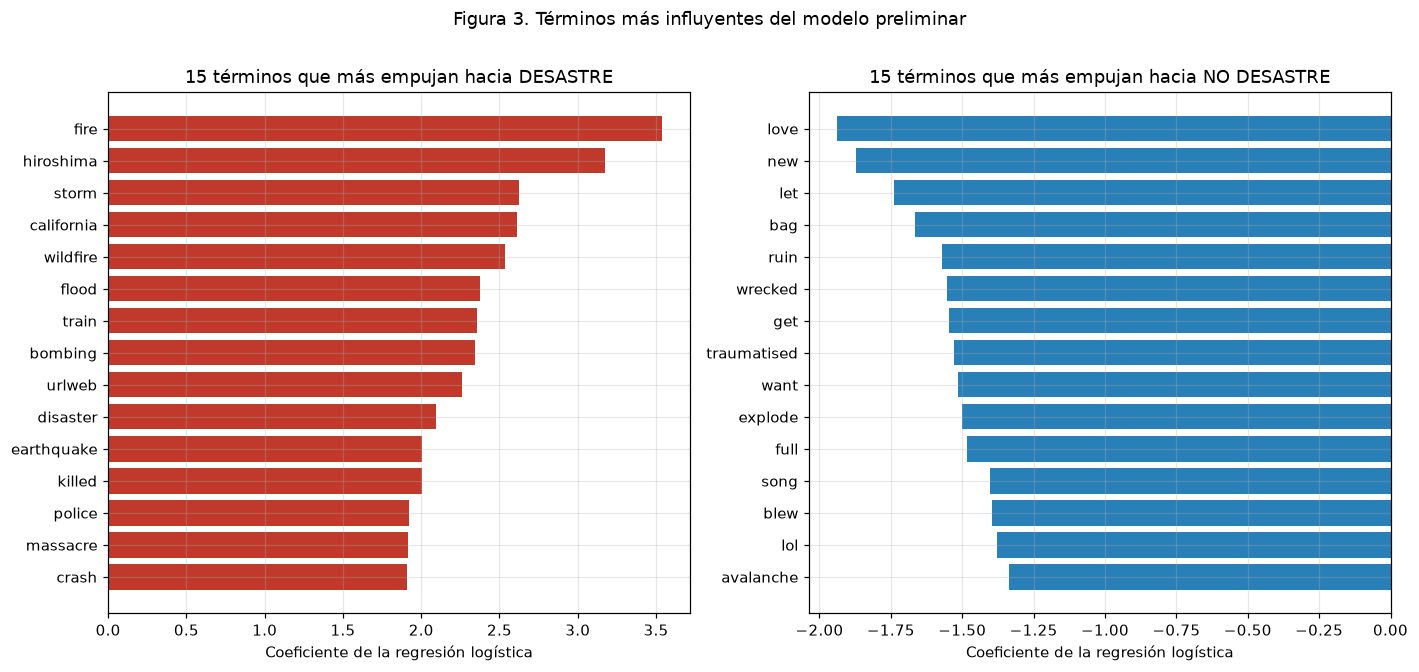

In [9]:
vectorizador = pipe_lr2.named_steps['vec']
clasificador = pipe_lr2.named_steps['clf']

coefs = pd.DataFrame({
    'termino': vectorizador.get_feature_names_out(),
    'coeficiente': clasificador.coef_[0],
})

top_desastre = coefs.nlargest(15, 'coeficiente')
top_no_desastre = coefs.nsmallest(15, 'coeficiente')

guardar_tabla(pd.concat([
    top_desastre.assign(empuja_hacia='desastre'),
    top_no_desastre.assign(empuja_hacia='no desastre'),
]), 'modelo_coeficientes_top15.csv')

print(f'Vocabulario del modelo: {len(coefs):,} términos')
fig, axes = plt.subplots(1, 2, figsize=(config.FIG_ANCHO + 3, config.FIG_ALTO + 1))

axes[0].barh(top_desastre.termino[::-1], top_desastre.coeficiente[::-1], color=config.COLOR_DESASTRE)
axes[0].set_title('15 términos que más empujan hacia DESASTRE')
axes[0].set_xlabel('Coeficiente de la regresión logística')

axes[1].barh(top_no_desastre.termino[::-1], top_no_desastre.coeficiente[::-1], color=config.COLOR_NO_DESASTRE)
axes[1].set_title('15 términos que más empujan hacia NO DESASTRE')
axes[1].set_xlabel('Coeficiente de la regresión logística')

fig.suptitle('Figura 3. Términos más influyentes del modelo preliminar', y=1.01)
fig.tight_layout()
guardar(fig, 'modelo_coeficientes.png')
plt.show()

**Interpretación.** Los coeficientes son legibles y coherentes con el dominio, lo que ya es
un resultado: el modelo no aprendió artefactos del archivo sino vocabulario de catástrofe.
Del lado de desastre están `fire`, `hiroshima`, `storm`, `california`, `wildfire`, `flood`,
`bombing`, `earthquake` y `killed`. Aparece también `urlweb`, el token que sustituyó a las
URLs, con un coeficiente alto: **el modelo confirma por su cuenta la decisión de
preprocesamiento de no borrar los enlaces**, que se había tomado a partir de la diferencia
del 67.35% contra 41.73% medida en el análisis exploratorio. Si se hubieran eliminado, esa
señal se habría perdido.

El lado contrario es el más interesante. Junto al vocabulario conversacional esperable
—`love`, `new`, `let`, `get`, `want`, `song`, `lol`— aparecen tres términos que son
vocabulario de catástrofe puro: **`explode`, `avalanche` y `traumatised` empujan hacia NO
desastre.** No es un error del modelo: es la medición directa del uso figurado. Se tuitea
*"my head is going to explode"* o *"an avalanche of emails"* mucho más de lo que se reporta
una explosión o un alud real. El modelo aprendió que, en este corpus, esas palabras concretas
son mejor indicio de hipérbole que de catástrofe.

Esto refina el hallazgo central del laboratorio. No es solo que el vocabulario de desastre sea
ambiguo: es que **algunos términos de desastre son activamente contraindicativos**, y su
efecto sobre la clasificación es el opuesto al que sugeriría la intuición.

### Contraste con el análisis discriminativo de n-gramas

El cuaderno de n-gramas calculó, sin entrenar ningún modelo, el log-ratio
`log( P(t | desastre) / P(t | no_desastre) )` de cada término. Si los términos que el modelo
aprendió a pesar con fuerza coinciden con los que aquel conteo señaló, se trata de dos
métodos independientes llegando a la misma conclusión, lo que es una validación cruzada
genuina y no una comprobación circular.

In [10]:
disc = pd.read_csv(config.TABLES / 'ngramas_discriminativo_completo.csv')

top_disc_des = set(disc.nlargest(50, 'logratio').palabra)
top_disc_no = set(disc.nsmallest(50, 'logratio').palabra)

coincide_des = [t for t in top_desastre.termino if t in top_disc_des]
coincide_no = [t for t in top_no_desastre.termino if t in top_disc_no]

print(f'De los 15 términos del modelo que empujan a DESASTRE, {len(coincide_des)} están')
print(f'entre los 50 de mayor log-ratio del análisis de n-gramas:')
print(' ', ', '.join(coincide_des) if coincide_des else '(ninguno)')
print()
print(f'De los 15 que empujan a NO DESASTRE, {len(coincide_no)} están entre los 50 de menor log-ratio:')
print(' ', ', '.join(coincide_no) if coincide_no else '(ninguno)')

comparacion = coefs.merge(disc[['palabra', 'logratio']], left_on='termino', right_on='palabra')
correlacion = comparacion['coeficiente'].corr(comparacion['logratio'], method='spearman')
print()
print(f'Términos presentes en ambos análisis: {len(comparacion):,}')
print(f'Correlación de Spearman entre coeficiente y log-ratio: {correlacion:.4f}')

De los 15 términos del modelo que empujan a DESASTRE, 4 están
entre los 50 de mayor log-ratio del análisis de n-gramas:
  hiroshima, wildfire, bombing, killed

De los 15 que empujan a NO DESASTRE, 5 están entre los 50 de menor log-ratio:
  bag, ruin, wrecked, song, blew

Términos presentes en ambos análisis: 2,549
Correlación de Spearman entre coeficiente y log-ratio: 0.8590


**Interpretación.** Los dos métodos coinciden, y la medida que lo demuestra es la
correlación de Spearman de **0.8590** entre el coeficiente aprendido y el log-ratio contado,
sobre los 2,549 términos presentes en ambos análisis. Es una correlación alta: el modelo
ordena el vocabulario prácticamente igual que lo hacía el conteo de frecuencias por clase,
pese a que uno optimiza una función de pérdida y el otro solo cuenta.

El solapamiento entre los extremos es más modesto —4 de 15 términos hacia desastre y 5 de 15
hacia no desastre aparecen entre los 50 más extremos del log-ratio— y esa diferencia también
es informativa. El log-ratio evalúa cada palabra **aislada**, mientras que la regresión
logística asigna coeficientes **con las demás palabras presentes**: reparte el peso entre
términos correlacionados en vez de premiar a todos por igual. Que el orden global coincida
tanto y los extremos difieran algo es exactamente lo que cabe esperar de dos métodos que
miden lo mismo por caminos distintos.

Los términos que sí coinciden en ambos extremos son los más reveladores. `bag` es el término
que más empuja hacia "no desastre" en los dos análisis, y viene casi por completo de la
expresión `body bag`, que el análisis exploratorio ya había señalado como el caso más claro
de vocabulario de catástrofe usado en sentido no literal. `ruin`, `wrecked` y `blew` están
ahí por la misma razón. **El modelo aprendió por su cuenta el hallazgo central del análisis
exploratorio**, sin que nadie se lo programara.

## Puesta a prueba de la hipótesis 1: ¿ayuda `keyword`?

El análisis exploratorio concluyó que `keyword` *"debe incorporarse como característica al
modelo del ejercicio 6"*, y el argumento era sólido: catálogo cerrado de 221 términos, apenas
0.80% de nulos, y tasas de desastre que van del 0% al 100%. La recomendación merece
comprobarse antes de darla por buena, y comprobarla es barato.

Se compara el mejor modelo consigo mismo, añadiéndole `keyword` codificada con
`OneHotEncoder` dentro de un `ColumnTransformer`. Todo sigue dentro del `Pipeline`, así que
la codificación también se ajusta solo con el conjunto de entrenamiento y
`handle_unknown='ignore'` gestiona cualquier keyword no vista.

In [11]:
transformador = ColumnTransformer([
    ('texto', TfidfVectorizer(ngram_range=(1, 2), min_df=2), 'text_clean'),
    ('keyword', OneHotEncoder(handle_unknown='ignore'), ['keyword_norm']),
])

pipe_kw = Pipeline([
    ('features', transformador),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=config.SEED)),
])
pipe_kw.fit(X_tr[['text_clean', 'keyword_norm']], y_tr)
pred_kw = pipe_kw.predict(X_te[['text_clean', 'keyword_norm']])

p, r, f, _ = precision_recall_fscore_support(y_te, pred_kw, labels=[0, 1], zero_division=0)
fila_kw = {
    'modelo': 'TF-IDF (1,2) + keyword one-hot + LogReg',
    'representacion': 'ColumnTransformer', 'algoritmo': 'LogisticRegression', 'texto': 'text_clean',
    'accuracy': accuracy_score(y_te, pred_kw),
    'precision_no_desastre': p[0], 'recall_no_desastre': r[0], 'f1_no_desastre': f[0],
    'precision_desastre': p[1], 'recall_desastre': r[1], 'f1_desastre': f[1],
    'macro_f1': f1_score(y_te, pred_kw, average='macro'),
}

comparativa_kw = pd.DataFrame([
    {k: v for k, v in tabla[tabla.modelo == 'TF-IDF (1,2) + LogReg'].iloc[0].items()},
    fila_kw,
])[['modelo', 'accuracy', 'f1_desastre', 'macro_f1']]

print('Efecto de añadir `keyword` como característica one-hot:')
print()
print(comparativa_kw.round(4).to_string(index=False))
print()
print(f"Diferencia en macro-F1: {fila_kw['macro_f1'] - tabla[tabla.modelo == 'TF-IDF (1,2) + LogReg'].macro_f1.iloc[0]:+.4f}")

Efecto de añadir `keyword` como característica one-hot:

                                 modelo  accuracy  f1_desastre  macro_f1
                  TF-IDF (1,2) + LogReg    0.7923       0.7482    0.7857
TF-IDF (1,2) + keyword one-hot + LogReg    0.7729       0.7297    0.7669

Diferencia en macro-F1: -0.0187


In [12]:
# ¿Por qué no ayuda? Porque la keyword casi siempre YA está escrita en el texto del tweet.
con_kw = df[df.keyword_norm != 'sin_keyword'].copy()
con_kw['kw_en_texto'] = con_kw.apply(
    lambda fila: any(parte in fila['text'].lower() for parte in fila['keyword_norm'].split()), axis=1)

print(f'Tweets con keyword:                              {len(con_kw):,}')
print(f'La keyword aparece literalmente dentro del texto: {con_kw.kw_en_texto.mean() * 100:.2f}%')
print(f'Categorías que añade el one-hot al modelo:        {df.keyword_norm.nunique()}')

Tweets con keyword:                              7,429
La keyword aparece literalmente dentro del texto: 94.10%
Categorías que añade el one-hot al modelo:        222


**Interpretación: la hipótesis no sobrevive.** Añadir `keyword` **empeora** el modelo, de
0.7857 a 0.7669 de macro-F1. La explicación está en la última celda: **la keyword ya aparece
escrita dentro del texto del tweet en el 94.10% de los casos**, así que el TF-IDF ya la había
capturado como un token más. El one-hot no aporta información nueva; lo que aporta son 222
columnas dispersas adicionales, la mayoría con muy pocos ejemplos cada una, que diluyen los
pesos y hacen que el modelo se ajuste a particularidades del conjunto de entrenamiento.

Vale la pena separar dos cosas que es fácil confundir. Que `keyword` sea **informativa** es
cierto y el análisis exploratorio lo demostró bien: sus tasas de desastre van del 0% al 100%.
Que sea **informativa de forma adicional al texto** es una afirmación distinta, y es la que
resulta falsa. Una variable redundante con lo que el modelo ya tiene no suma, y si además
llega en forma dispersa, resta.

Esto no invalida el análisis exploratorio: `keyword` sigue siendo la herramienta de
diagnóstico más útil del laboratorio, y de hecho es lo que permite hacer el análisis de
errores de la siguiente sección. Lo que cambia es su papel: **sirve para entender el
problema, no para alimentar el modelo.**

## Puesta a prueba de la hipótesis 2: ¿se concentran los errores en el lenguaje figurado?

El análisis exploratorio predijo que los errores del clasificador *"deberían concentrarse en
las keywords de tasa intermedia"*, porque son las que corresponden a vocabulario de catástrofe
con doble vida: `aftershock`, `ruin` o `body bag` se usan constantemente en sentido figurado,
mientras que `derailment` o `debris` casi nunca.

Para comprobarlo se agrupan las keywords según su tasa de desastre y se mide la tasa de error
del modelo en cada grupo. **La tasa de cada keyword se calcula únicamente sobre el conjunto de
entrenamiento**: usar el de prueba para construir el criterio con el que después se juzgan
los errores sobre ese mismo conjunto sería fuga de información.

In [13]:
tasa_train = (X_tr.assign(target=y_tr)
              .groupby('keyword_norm')['target']
              .agg(tasa_desastre='mean', n_train='size'))

errores = X_te.assign(real=y_te, pred=pred_lr2)
errores['error'] = (errores.real != errores.pred).astype(int)
errores = errores.join(tasa_train, on='keyword_norm').dropna(subset=['tasa_desastre'])

errores['grupo'] = pd.cut(
    errores.tasa_desastre, [-0.001, 0.2, 0.8, 1.001],
    labels=['Extrema baja\n(tasa <= 0.2)', 'Intermedia\n(0.2 < tasa <= 0.8)', 'Extrema alta\n(tasa > 0.8)'])

por_grupo = (errores.groupby('grupo', observed=True)
             .agg(tasa_error=('error', 'mean'), tweets=('error', 'size'), errores=('error', 'sum'))
             .reset_index())
guardar_tabla(por_grupo, 'modelo_errores_por_keyword.csv')
print(por_grupo.round(4).to_string(index=False))

tabla guardada: modelo_errores_por_keyword.csv
                          grupo  tasa_error  tweets  errores
    Extrema baja\n(tasa <= 0.2)      0.1688     468       79
Intermedia\n(0.2 < tasa <= 0.8)      0.2503     855      214
     Extrema alta\n(tasa > 0.8)      0.1034     174       18


figura guardada: modelo_errores_por_keyword.png


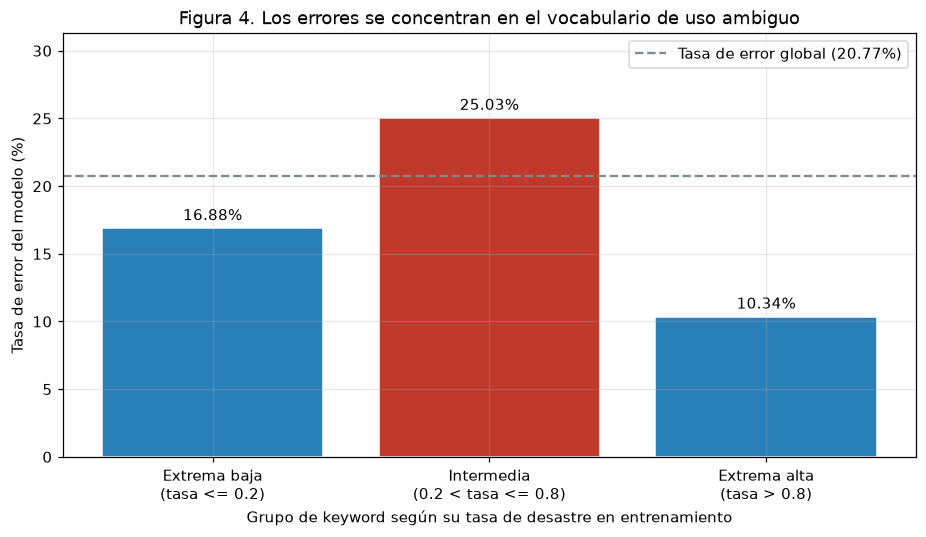


Keywords con más errores (mínimo 5 tweets en prueba):
                  errores  tweets  tasa_train  tasa_error
keyword_norm                                             
lightning               6      12       0.571       0.500
natural disaster        6       8       0.560       0.750
war zone                6       9       0.067       0.667
cyclone                 5      11       0.714       0.455
fire                    5       9       0.345       0.556
bioterror               4       6       0.581       0.667
collapsed               4       8       0.370       0.500
disaster                4       8       0.481       0.500
hazardous               4       5       0.680       0.800
hijacker                4      13       0.450       0.308


In [14]:
fig, ax = plt.subplots(figsize=(config.FIG_ANCHO, config.FIG_ALTO))
colores_grupo = [config.COLOR_NO_DESASTRE, config.COLOR_DESASTRE, config.COLOR_NO_DESASTRE]
barras = ax.bar(por_grupo.grupo.astype(str), por_grupo.tasa_error * 100,
                color=colores_grupo, edgecolor='white')
ax.bar_label(barras, fmt='%.2f%%', padding=3)

tasa_global = errores.error.mean() * 100
ax.axhline(tasa_global, color=config.COLOR_NEUTRO, linestyle='--', linewidth=1.5,
           label=f'Tasa de error global ({tasa_global:.2f}%)')
ax.set_ylabel('Tasa de error del modelo (%)')
ax.set_xlabel('Grupo de keyword según su tasa de desastre en entrenamiento')
ax.set_title('Figura 4. Los errores se concentran en el vocabulario de uso ambiguo')
ax.set_ylim(0, max(por_grupo.tasa_error * 100) * 1.25)
ax.legend()
guardar(fig, 'modelo_errores_por_keyword.png')
plt.show()

peores = (errores.groupby('keyword_norm')
          .agg(errores=('error', 'sum'), tweets=('error', 'size'), tasa_train=('tasa_desastre', 'first')))
peores = peores[peores.tweets >= 5].assign(tasa_error=lambda d: d.errores / d.tweets)
print('\nKeywords con más errores (mínimo 5 tweets en prueba):')
print(peores.nlargest(10, 'errores').round(3).to_string())

**Interpretación: la hipótesis se confirma.** La tasa de error en las keywords de tasa
intermedia es del **25.03%**, frente al 16.88% de las de tasa extrema baja y el 10.34% de las
de tasa extrema alta. Un tweet cuya keyword es ambigua tiene **casi dos veces y media** más
probabilidad de ser mal clasificado que uno cuya keyword es inequívoca.

El listado de las keywords con más errores lo hace todavía más concreto. `natural disaster`
falla en 6 de 8 tweets y `war zone` en 6 de 9: son expresiones que la gente usa
constantemente como hipérbole —*"my kitchen is a war zone"*— y el modelo, que solo ve
palabras, no tiene forma de distinguir la hipérbole del reporte literal. `lightning` falla en
la mitad de sus casos por la misma razón.

Esto responde con evidencia a la pregunta del enunciado sobre **cómo se planea abordar el
contexto**: el problema no es que falten palabras, es que las mismas palabras significan
cosas distintas según el contexto, y una bolsa de palabras no representa contexto por
construcción. Los bigramas son el primer intento de capturarlo y ya se midió que aportan
poco. La conclusión honesta es que **superar este techo exige una representación que
distinga sentido literal de figurado**, y eso son embeddings contextuales, no n-gramas.

## Robustez de la elección: validación cruzada

Toda la comparación anterior descansa sobre una única partición. Antes de declarar un modelo
preliminar conviene comprobar que la ventaja no es un accidente de esa partición concreta,
así que se repite la evaluación con validación cruzada estratificada de 5 pliegues **sobre el
conjunto de entrenamiento**. El conjunto de prueba no participa: sigue reservado.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.SEED)

candidatos = {
    'TF-IDF (1,1) + LogReg': (Pipeline([
        ('vec', TfidfVectorizer(ngram_range=(1, 1), min_df=2)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=config.SEED))]),
        X_tr['text_clean']),
    'TF-IDF (1,2) + LogReg': (Pipeline([
        ('vec', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=config.SEED))]),
        X_tr['text_clean']),
    'TF-IDF (1,2) + MultinomialNB': (Pipeline([
        ('vec', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ('clf', MultinomialNB())]),
        X_tr['text_clean']),
    'TF-IDF (1,2) + keyword one-hot + LogReg': (pipe_kw, X_tr[['text_clean', 'keyword_norm']]),
}

filas_cv = []
for nombre, (pipe, datos) in candidatos.items():
    puntajes = cross_val_score(pipe, datos, y_tr, cv=cv, scoring='f1_macro')
    filas_cv.append({'modelo': nombre, 'macro_f1_medio': puntajes.mean(),
                     'desviacion': puntajes.std(), 'minimo': puntajes.min(), 'maximo': puntajes.max()})

tabla_cv = pd.DataFrame(filas_cv).sort_values('macro_f1_medio', ascending=False).reset_index(drop=True)
guardar_tabla(tabla_cv, 'modelo_validacion_cruzada.csv')
tabla_cv.round(4)

tabla guardada: modelo_validacion_cruzada.csv


,modelo,macro_f1_medio,desviacion,minimo,maximo
0,"TF-IDF (1,2) + LogReg",0.7954,0.0130,0.7769,0.8122
1,"TF-IDF (1,1) + LogReg",0.7946,0.0142,0.7717,0.8088
2,"TF-IDF (1,2) + MultinomialNB",0.7889,0.0121,0.7655,0.7987
3,"TF-IDF (1,2) + keyword one-hot + LogReg",0.7842,0.0080,0.7720,0.7950


**Interpretación.** La validación cruzada confirma el orden observado en el conjunto de
prueba y despeja las dos dudas que quedaban abiertas.

La regresión logística con TF-IDF encabeza en ambas evaluaciones, y su desviación estándar
entre pliegues (±0.0130) es pequeña comparada con la distancia que la separa de Naive Bayes y
de la variante con `keyword`. La caída al añadir `keyword` **se reproduce en la validación
cruzada**, no solo en la partición de prueba: eso descarta que fuera un accidente de una
partición desafortunada y confirma el diagnóstico de redundancia.

Sobre los bigramas, la diferencia entre el rango (1,1) y el (1,2) sigue siendo mucho menor
que la variabilidad entre pliegues, lo que refuerza la lectura anterior: **no hay evidencia
de que aporten**, aunque tampoco perjudican.

## Modelo preliminar seleccionado

**TF-IDF con rango de n-gramas (1,2) y `min_df=2`, más regresión logística con
`class_weight='balanced'`, entrenada sobre `text_clean`.**

| Aspecto | Elección | Motivo |
|---|---|---|
| Representación | `TfidfVectorizer(ngram_range=(1,2), min_df=2)` | TF-IDF pondera a la baja los términos presentes en muchos documentos, que es el problema que el análisis exploratorio identificó con las palabras compartidas entre clases |
| Algoritmo | `LogisticRegression(class_weight='balanced', max_iter=1000)` | Mejor macro-F1, y sus coeficientes son auditables término a término |
| Texto | `text_clean` (lematizado, con números) | Supera a `text_stem` y conserva palabras reales |
| Partición | 80/20 estratificada, `random_state=42` | Congelada en `data/processed/particion.parquet` |
| Métrica | macro-F1 | El desbalance 57/43 vuelve engañosa la exactitud |

Resultado sobre el conjunto de prueba: **macro-F1 = 0.7857**, exactitud 79.23%, frente a un
baseline de 0.3646. La clase desastre alcanza precisión 0.7739 y exhaustividad 0.7241.

Conviene poner ese 79% en perspectiva. El propio conjunto contiene 18 textos idénticos
etiquetados de forma contradictoria por anotadores humanos, lo que significa que **ni las
personas coinciden consigo mismas** en los casos límite. El techo alcanzable no es 100%, y
buena parte de la distancia que queda corresponde a tweets genuinamente ambiguos.

### Plan para la entrega final

Lo que se hará, ordenado por lo que la evidencia de hoy sugiere que rendirá más:

1. **Mover el umbral de decisión.** Los 176 falsos negativos contra 135 falsos positivos
   muestran que el umbral por defecto de 0.5 no es el adecuado para un problema donde no
   detectar un desastre es el error caro. Se elegirá el umbral maximizando macro-F1 sobre
   validación cruzada, nunca sobre el conjunto de prueba.
2. **Ampliar a las doce combinaciones** previstas, incorporando `RandomForest` y
   `LinearSVC` con TF-IDF, y ajustando `min_df`, `max_features` y la regularización `C` con
   `GridSearchCV` sobre el conjunto de entrenamiento.
3. **Integrar la variable de negatividad** del ejercicio 10 sobre esta misma partición
   congelada. La comparación será limpia precisamente porque el conjunto de prueba no cambia.
   La expectativa, a partir del análisis exploratorio, es que aporte poco: los tweets de
   desastre resultaron ser más factuales y menos emocionales, no más negativos.
4. **Construir la función de clasificación del ejercicio 7** sobre este pipeline. Recibirá
   texto crudo, le aplicará `pipeline_texto` y devolverá la etiqueta; que el preprocesamiento
   viva dentro del `Pipeline` de scikit-learn es lo que garantiza que un tweet nuevo reciba
   exactamente el mismo tratamiento que los de entrenamiento.
5. **No se insistirá con `keyword` como característica** ni con los trigramas. Ambos quedaron
   medidos hoy y ninguno de los dos aporta.

In [16]:
import joblib

joblib.dump(pipe_lr2, config.MODELOS / 'modelo_preliminar.joblib')
print(f'Modelo preliminar guardado en {(config.MODELOS / "modelo_preliminar.joblib").relative_to(RAIZ)}')

print()
print('Resumen del avance del ejercicio 6')
print('=' * 58)
print(f'  Modelo preliminar .... TF-IDF (1,2) + LogisticRegression')
print(f'  macro-F1 (prueba) .... {tabla.macro_f1.max():.4f}')
print(f'  macro-F1 (baseline) .. {fila_base["macro_f1"]:.4f}')
print(f'  Mejora sobre baseline  {tabla.macro_f1.max() - fila_base["macro_f1"]:+.4f}')

Modelo preliminar guardado en results/modelos/modelo_preliminar.joblib

Resumen del avance del ejercicio 6
  Modelo preliminar .... TF-IDF (1,2) + LogisticRegression
  macro-F1 (prueba) .... 0.7857
  macro-F1 (baseline) .. 0.3646
  Mejora sobre baseline  +0.4211
